# SEAS5 skill

Loads ERA5 and SEAS5 monthly data for a PCODE, and produces skill plots per leadtime.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.datasources import seas5, era5
from src.utils.rp_calc import calculate_one_group_rp

## Set parameters

In [12]:
pcode = "SS"
min_year = 1981
max_year = 2024

## Load and combine data

In [13]:
df_era5 = era5.load_era5(pcode=pcode)

<Axes: xlabel='valid_date'>

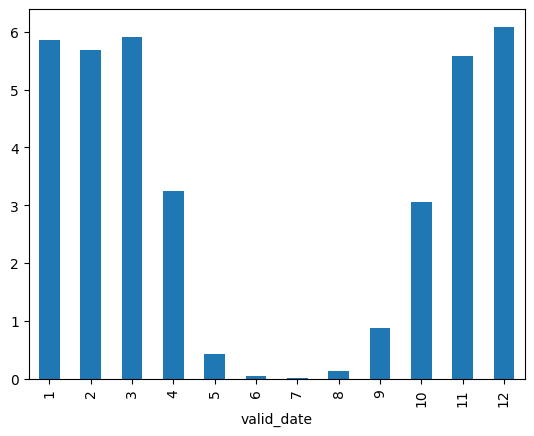

In [22]:
df_era5.groupby(df_era5["valid_date"].dt.month)["mean"].mean().plot.bar()

In [14]:
df_seas5 = seas5.load_seas5(pcode=pcode)

In [15]:
df_compare = df_seas5.merge(
    df_era5,
    on=["valid_date", "pcode", "adm_level", "iso3"],
    suffixes=["_s", "_e"],
    how="left",
)
df_compare = df_compare[
    (df_compare["valid_date"].dt.year >= min_year)
    & (df_compare["valid_date"].dt.year <= max_year)
]

## Calculate metrics

In [16]:
rp = 5
low_is_bad = False
dicts = []
for i_mo in range(1, 13):
    for v_mo in range(i_mo, i_mo + 7):
        v_mo = (v_mo - 1) % 12 + 1
        dff = (
            df_compare[
                (df_compare["valid_date"].dt.month == v_mo)
                & (df_compare["issued_date"].dt.month == i_mo)
            ]
            .groupby("issued_date")[["mean_s", "mean_e"]]
            .mean()
            .reset_index()
        )
        dff["year"] = dff["issued_date"].dt.year
        for l in ["s", "e"]:
            dff = calculate_one_group_rp(
                dff, col_name=f"mean_{l}", ascending=low_is_bad
            )

        dff["P"] = dff["mean_e_rp"] >= rp
        dff["PP"] = dff["mean_s_rp"] >= rp
        dff["TP"] = dff[["P", "PP"]].all(axis=1)
        tp = dff["TP"].sum()
        p = dff["P"].sum()
        tpr = tp / p
        corr = dff.corr().loc["mean_s", "mean_e"]
        dicts.append({"i_mo": i_mo, "v_mo": v_mo, "corr": corr, "tpr": tpr})
df_corr = pd.DataFrame(dicts)
df_corr["lt"] = (df_corr["v_mo"] - df_corr["i_mo"]) % 12

In [17]:
df_corr

,i_mo,v_mo,corr,tpr,lt
0,1,1,0.635720,0.666667,0
1,1,2,0.135144,0.333333,1
2,1,3,0.176605,0.444444,2
3,1,4,-0.023481,0.111111,3
4,1,5,0.239926,0.333333,4
...,...,...,...,...,...
79,12,2,0.200339,0.250000,2
80,12,3,0.203324,0.500000,3
81,12,4,0.213607,0.375000,4
82,12,5,-0.076856,0.250000,5


## Plot

### Align valid months

Text(0.5, 1.0, 'SEAS5-ERA5 recall/precision/F-1 for AO\n5-year RP')

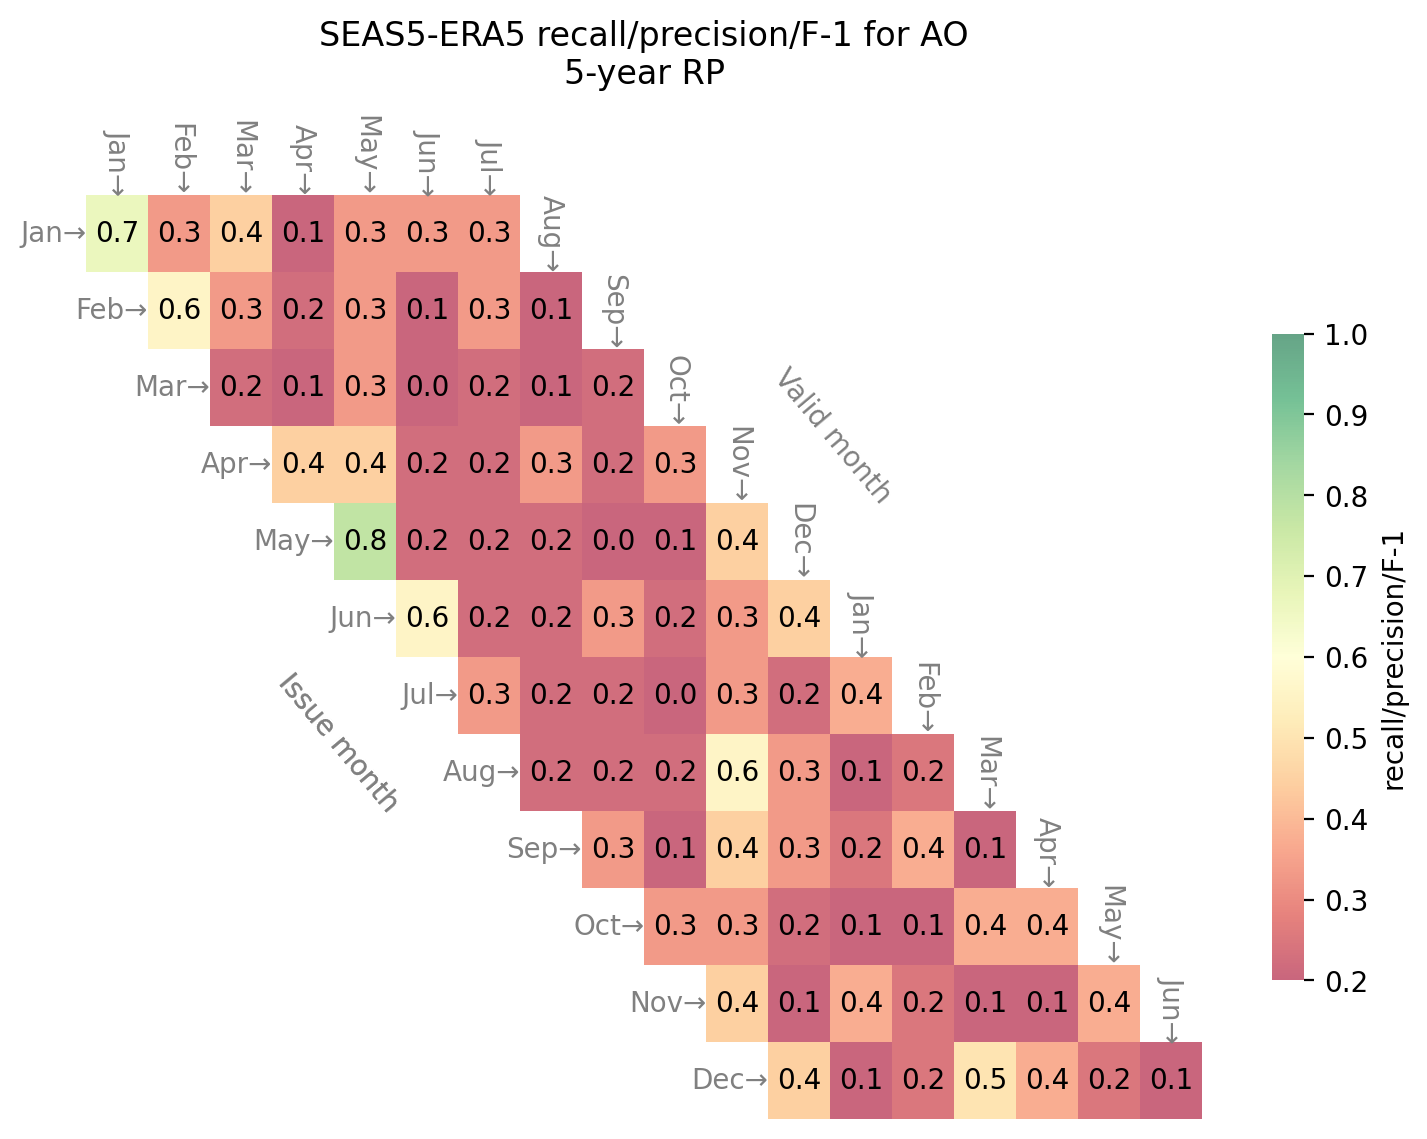

In [18]:
season_months = [7, 8, 9]

metric = "tpr"

if metric == "tpr":
    metric_str = "recall/precision/F-1"
    title_append = f"\n{rp}-year RP"
    vmin = 1 / rp
elif metric == "corr":
    metric_str = "correlation"
    vmin = 0
    title_append = ""
else:
    raise ValueError("wrong metric")

season_months_str = "".join([calendar.month_abbr[x][0] for x in season_months])

df_corr_wrap = df_corr.copy()
df_corr_wrap["v_mo_wrap"] = df_corr_wrap["i_mo"] + df_corr_wrap["lt"]
df_corr_pivot = df_corr_wrap.pivot(
    columns="v_mo_wrap", index="i_mo", values=metric
)

fig, ax = plt.subplots(dpi=200, figsize=(9, 6))

sns.heatmap(
    df_corr_pivot,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    cbar_kws={"label": metric_str, "shrink": 0.7},
    annot_kws={"color": "black"},
    ax=ax,
    vmax=1,
    vmin=vmin,
    alpha=0.6,
)

for i_mo in df_corr_pivot.index:
    ax.annotate(
        f"{calendar.month_abbr[i_mo]}→",
        (i_mo - 1, i_mo - 0.5),
        va="center",
        ha="right",
        color="grey",
        fontsize=10,
    )
ax.annotate("Issue month", (3, 8), rotation=-50, color="grey")

for v_mo in df_corr_pivot:
    y = v_mo - 7 if v_mo > 7 else 0
    v_mo_label = (v_mo - 1) % 12 + 1
    ax.annotate(
        f"{calendar.month_abbr[v_mo_label]}→",
        (v_mo - 0.5, y),
        va="bottom",
        ha="center",
        color="grey",
        fontsize=10,
        rotation=-90,
    )
ax.annotate("Issue month", (3, 8), rotation=-50, color="grey")
ax.annotate("Valid month", (11, 4), rotation=-50, color="grey")

ax.axis("off")

ax.set_title(f"SEAS5-ERA5 {metric_str} for {pcode}{title_append}", pad=40)

Text(0.5, 1.0, 'SEAS5-ERA5 correlation for AO')

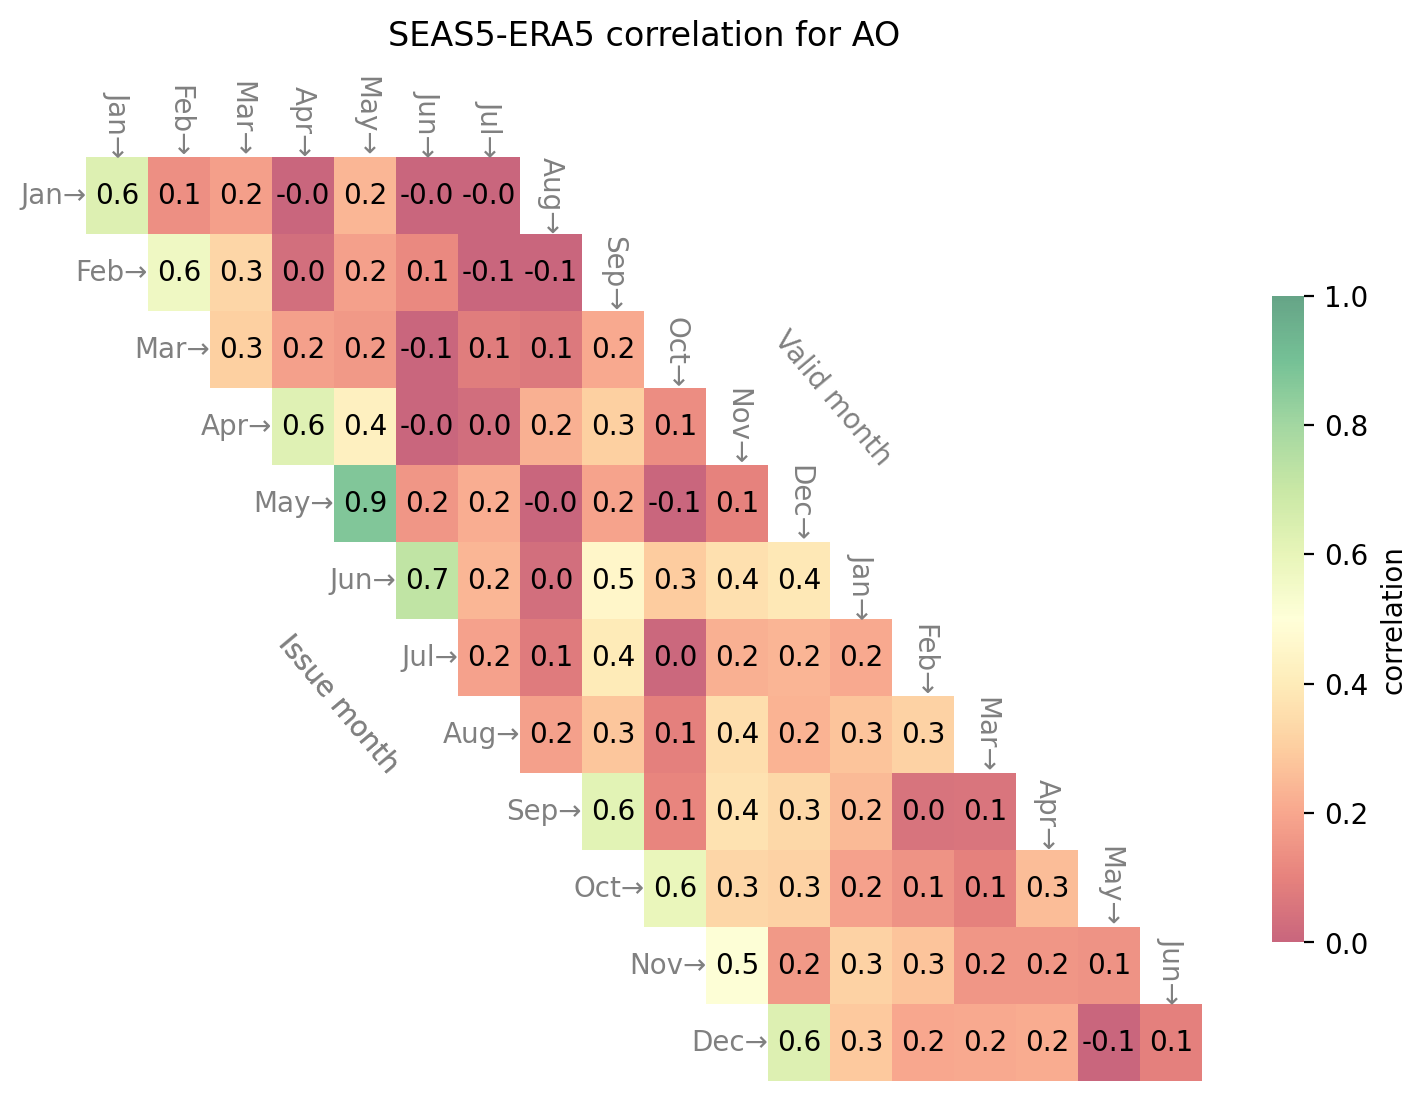

In [19]:
season_months = [7, 8, 9]

metric = "corr"

if metric == "tpr":
    metric_str = "recall/precision/F-1"
    title_append = f"\n{rp}-year RP"
    vmin = 1 / rp
elif metric == "corr":
    metric_str = "correlation"
    vmin = 0
    title_append = ""
else:
    raise ValueError("wrong metric")

season_months_str = "".join([calendar.month_abbr[x][0] for x in season_months])

df_corr_wrap = df_corr.copy()
df_corr_wrap["v_mo_wrap"] = df_corr_wrap["i_mo"] + df_corr_wrap["lt"]
df_corr_pivot = df_corr_wrap.pivot(
    columns="v_mo_wrap", index="i_mo", values=metric
)

fig, ax = plt.subplots(dpi=200, figsize=(9, 6))

sns.heatmap(
    df_corr_pivot,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    cbar_kws={"label": metric_str, "shrink": 0.7},
    annot_kws={"color": "black"},
    ax=ax,
    vmax=1,
    vmin=vmin,
    alpha=0.6,
)

for i_mo in df_corr_pivot.index:
    ax.annotate(
        f"{calendar.month_abbr[i_mo]}→",
        (i_mo - 1, i_mo - 0.5),
        va="center",
        ha="right",
        color="grey",
        fontsize=10,
    )
ax.annotate("Issue month", (3, 8), rotation=-50, color="grey")

for v_mo in df_corr_pivot:
    y = v_mo - 7 if v_mo > 7 else 0
    v_mo_label = (v_mo - 1) % 12 + 1
    ax.annotate(
        f"{calendar.month_abbr[v_mo_label]}→",
        (v_mo - 0.5, y),
        va="bottom",
        ha="center",
        color="grey",
        fontsize=10,
        rotation=-90,
    )
ax.annotate("Issue month", (3, 8), rotation=-50, color="grey")
ax.annotate("Valid month", (11, 4), rotation=-50, color="grey")

ax.axis("off")

ax.set_title(f"SEAS5-ERA5 {metric_str} for {pcode}{title_append}", pad=40)

### Align leadtimes

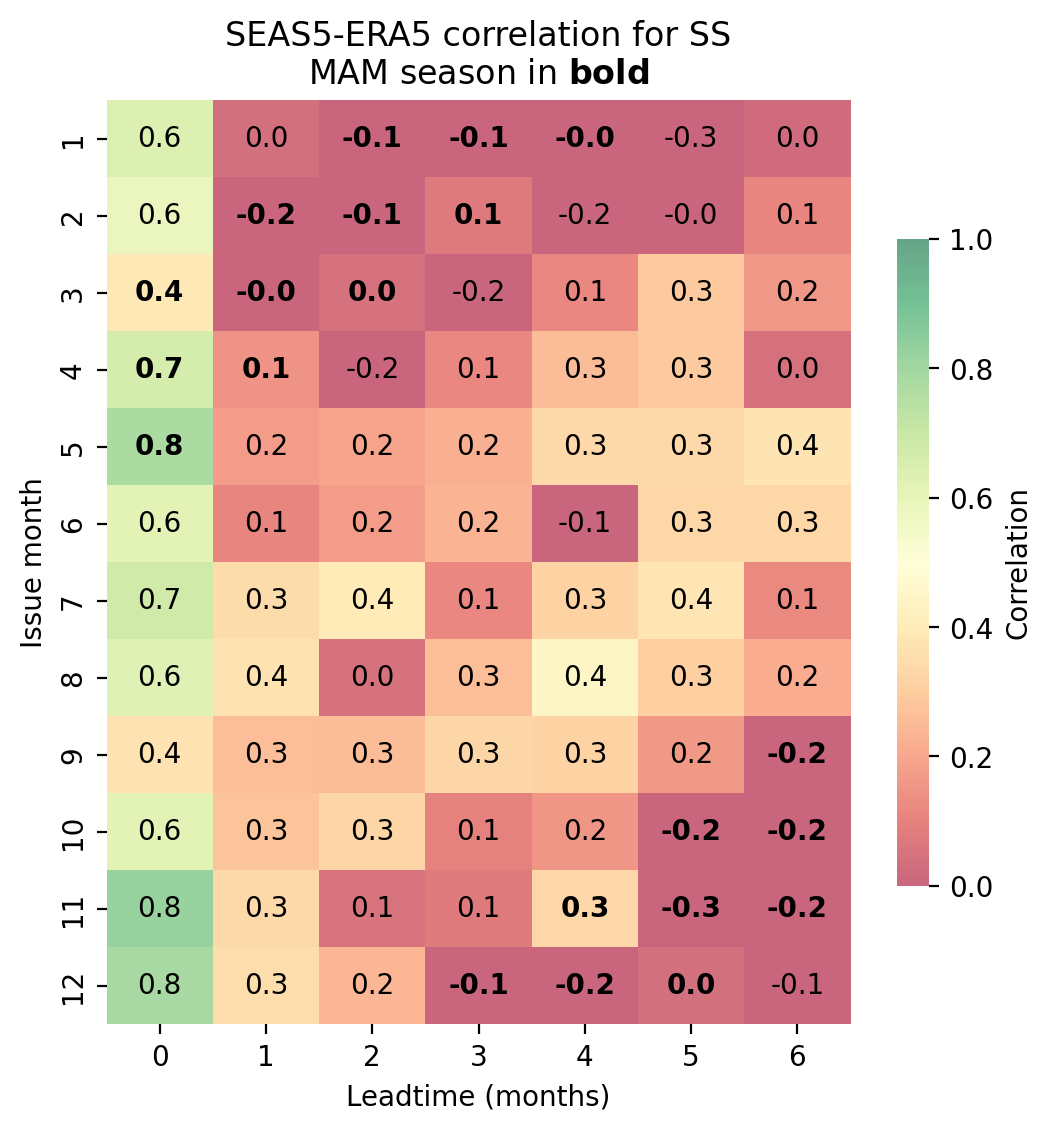

In [127]:
season_months = [3, 4, 5]

season_months_str = "".join([calendar.month_abbr[x][0] for x in season_months])

df_corr_pivot = df_corr.pivot(columns="lt", index="i_mo", values="corr")

df_condition = df_corr_pivot.astype(bool)

for lt in df_condition:
    df_condition[lt] = ((df_condition.index + lt - 1) % 12 + 1).isin(
        season_months
    )
condition = df_condition.to_numpy()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

sns.heatmap(
    df_corr_pivot,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    cbar_kws={"label": "Correlation", "shrink": 0.7},
    annot_kws={"color": "black"},
    ax=ax,
    vmax=1,
    vmin=0,
    alpha=0.6,
)

for y_idx in range(df_corr_pivot.shape[0]):  # Iterate over rows (lt)
    for x_idx in range(df_corr_pivot.shape[1]):  # Iterate over columns (i_mo)
        if condition[y_idx, x_idx]:
            # Get the annotation text and set it to bold
            text = ax.texts[y_idx * df_corr_pivot.shape[1] + x_idx]
            text.set_fontweight("bold")

# contour = ax.contour(condition, levels=[0.5], colors="black", linewidths=2)
plt.title(
    f"SEAS5-ERA5 correlation for {pcode}\n"
    f"{season_months_str} season in "
    r"$\bf{bold}$"
)
plt.xlabel("Leadtime (months)")
plt.ylabel("Issue month")
plt.show()